Mini-project: testing regularization

Idea: predict mouse body fat % from weight

Generate slightly noisy data:

In [223]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

m = 40
weight = np.linspace(10, 50, m)

# True relationship (nonlinear)
true_y = 0.05 * weight**2 - 2 * weight + 30

# Add noise
y = true_y + np.random.normal(0, 25, m)

Text(0, 0.5, 'Body fat %')

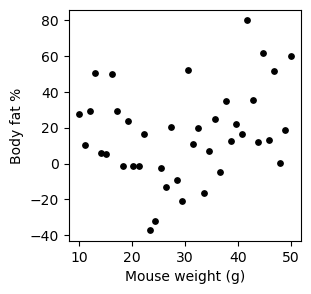

In [224]:
f, ax = plt.subplots(1,1,figsize=(3,3))
ax.scatter(weight, y, marker='o', s=15, color='black')
ax.set_xlabel("Mouse weight (g)")
ax.set_ylabel("Body fat %")

Create a complex, high-degree, polynomial model:

This model should wiggle like crazy

In [225]:
degree = 50

X = np.column_stack([weight**i for i in range(1, degree+1)])
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
Xs = (X - X_mean) / X_std

Let's train three version of the model:

- No regularization: $J = \frac{1}{2m} \sum(Xw - y)^2$

- L2 (ridge): $J = \frac{1}{2m} \sum (Xw-y)^2 + \frac{\lambda}{2m} \sum w_j^2$

- L1 (lasso): $J = \frac{1}{2m} \sum (Xw-y)^2 + \frac{\lambda}{2m} \sum |w_j|$

In [226]:
# No regularization
def loss_no_reg(X, y, w, b):
    yhat = X @ w + b
    return np.mean((yhat - y)**2)/2

# L2 (ridge)
def loss_l2(X, y, w, b, lam):
    base = loss_no_reg(X, y, w, b)
    return base + lam/(2*len(y)) * np.sum(w**2)

# L1 (lasso)
def loss_l1(X, y, w, b, lam):
    base = loss_no_reg(X, y, w, b)
    return base + lam/(2*len(y)) * np.sum(np.abs(w))

Then compute the gradients for gradient descent:

$\frac{\partial}{\partial w} J(w,b) = \frac{1}{m} \sum_{i=1}^m \left( \hat{y}^i - y^i \right)x^i$

$\frac{\partial}{\partial b} J(w,b) = \frac{1}{m} \sum_{i=1}^m \left( \hat{y}^i - y^i \right)$

$\frac{\partial}{\partial w} \left[ \frac{\lambda}{2m} \sum w_j^2 \right] = \frac{\lambda}{m} w_j$

$\frac{\partial}{\partial w} \left[ \frac{\lambda}{2m} \sum |w_j| \right] = \frac{\lambda}{2m} \mathrm{sign} (w_j) $

In [227]:
# No regularization
def gradients_no_reg(X, y, w, b):
    # X: (m,n), w: (n,), y: (m,)
    yhat = X @ w + b                   # (m,)
    dw = (X.T @ (yhat - y)) / len(y)   # (n,)
    db = np.mean(yhat - y)             # scalar
    return dw, db

# L2 (ridge)
def gradients_l2(X, y, w, b, lam):
    dw, db = gradients_no_reg(X, y, w, b)
    dw += lam/len(y) * w 
    return dw, db

# L1 (lasso)
def gradients_l1(X, y, w, b, lam):
    dw, db = gradients_no_reg(X, y, w, b)
    dw += lam/(2*len(y)) * np.sign(w)
    return dw, db

This time we define a training function (cleaner):

In [228]:
def train(X, y, lam=0, reg_type=None, lr=0.01, steps=1000):
    w = np.zeros(X.shape[1])
    b = 0.0

    loss_history = []

    # training loop
    for _ in range(steps):
        
        # get the gradients depending on regularization applied
        if reg_type == "l2":
            dw, db = gradients_l2(X, y, w, b, lam)
            loss_history.append(loss_l2(X, y, w, b, lam))
        elif reg_type == "l1":
            dw, db = gradients_l1(X, y, w, b, lam)
            loss_history.append(loss_l1(X, y, w, b, lam))
        else:
            dw, db = gradients_no_reg(X, y, w, b)
            loss_history.append(loss_no_reg(X, y, w, b))
        
        # update parameters
        w -= lr * dw
        b -= lr * db
    
    return w, b, loss_history

Train all three models:

In [237]:
w0, b0, h0 = train(Xs, y) # reg is set as None so it won't be applied

w_l2, b_l2, h_l2 = train(Xs, y, lam=20, reg_type="l2")

w_l1, b_l1, h_l1 = train(Xs, y, lam=30, reg_type="l1")

Plot the loss:

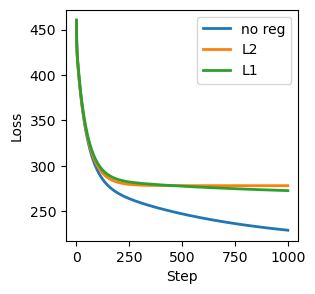

In [238]:
f, ax = plt.subplots(1,1, figsize=(3,3))
ax.plot(h0, lw=2, label='no reg')
ax.plot(h_l2, lw=2, label='L2')
ax.plot(h_l1, lw=2, label='L1')
ax.set_xlabel("Step")
ax.set_ylabel('Loss')
ax.legend()

Plot the models:

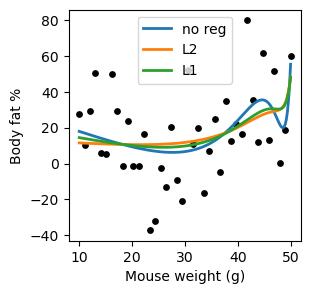

In [239]:
# 1) raw x values for the plot (grams)
x_plot = np.linspace(weight.min(), weight.max(), 200)

# 2) build polynomial features for those x values
X_plot = np.column_stack([x_plot**i for i in range(1, degree+1)])

# 3) standardize using TRAINING mean/std (X_mean, X_std)
Xs_plot = (X_plot - X_mean) / (X_std + 1e-8)

# 4) predict
y0_plot = Xs_plot @ w0 + b0
y_l2_plot = Xs_plot @ w_l2 + b_l2
y_l1_plot = Xs_plot @ w_l1 + b_l1

# 5) plot
f, ax = plt.subplots(1,1, figsize=(3,3))
ax.scatter(weight, y, marker='o', s=15, color='black')
ax.plot(x_plot, y0_plot, lw=2, label='no reg')
ax.plot(x_plot, y_l2_plot, lw=2, label='L2')
ax.plot(x_plot, y_l1_plot, lw=2, label='L1')
ax.set_xlabel("Mouse weight (g)")
ax.set_ylabel("Body fat %")
ax.legend()

Compare the resulting weights:

In [240]:
print("No reg weights:\n", w0)
print("\nL2 weights:\n", w_l2)
print("\nL1 weights:\n", w_l1)

No reg weights:
 [-11.29021456  -1.85688046   3.84437076   6.47983618   7.12938334
   6.66564189   5.65692535   4.43740809   3.19158796   2.01562399
   0.95555228   0.02960262  -0.759135    -1.41559505  -1.94874335
  -2.36933084  -2.68862949  -2.91772721  -3.06714544  -3.14664611
  -3.16515052  -3.13072489  -3.05060493  -2.93124235  -2.77836293
  -2.59702921  -2.39170381  -2.16631068  -1.9242929   -1.66866616
  -1.40206759  -1.12679989  -0.84487095  -0.55802917  -0.2677948
   0.02451231   0.31774824   0.61092347   0.90318395   1.19379452
   1.48212427   1.76763385   2.0498642    2.32842676   2.6029949
   2.87329631   3.13910643   3.4002426    3.65655897   3.90794198]

L2 weights:
 [-1.95462874  0.23039405  1.52525499  2.09511899  2.19588302  2.03343014
  1.74244179  1.40284241  1.05929986  0.73542369  0.44268944  0.18571946
 -0.03466923 -0.21971943 -0.3717336  -0.49349914 -0.58795821 -0.65801979
 -0.7064556  -0.73584614 -0.74855694 -0.74673284 -0.7323031  -0.70699269
 -0.67233673 -0.62

In [12]:
from collections import Counter

In [13]:
list1 = ['exo','we are one']
list2 = ['growl','tempo','love shot','kokobop','universe','monster','power','obsession','let me in','lotto','crown','gravity','for life','el dorado','dont go','first snow','back it up','love me right','groove','lucky one']
list3 = ['overdose','mama','angel','lucky','diamond','love fool','forever','sing for you','been through','moonlight']

In [11]:
len(list1)*20+len(list2)+len(list3)

70

In [18]:
counts = Counter()

# 20 EXO + 20 WE ARE ONE
counts.update(('exo'*10).replace(' ',''))
counts.update(('we are one'*10).replace(' ',''))

# 1 bracelet per song
for s in list2 + list3:
    counts.update(s.replace(' ',''))

print(dict(sorted(counts.items())))

{'a': 17, 'b': 4, 'c': 4, 'd': 6, 'e': 63, 'f': 6, 'g': 9, 'h': 5, 'i': 11, 'k': 5, 'l': 13, 'm': 8, 'n': 23, 'o': 56, 'p': 4, 'r': 26, 's': 10, 't': 13, 'u': 6, 'v': 8, 'w': 14, 'x': 10, 'y': 4}


In [19]:
total_pearls = sum(counts.values())

print("Total alphabet pearls needed:", total_pearls)

Total alphabet pearls needed: 325
